In [3]:
from google.colab import files
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from google.colab import auth
auth.authenticate_user()
print("Authenticated!")

Authenticated!


In [5]:
from google.cloud import bigquery

project_id = 'mc-ut-msai-aih-1'
client = bigquery.Client(project=project_id)
print("BigQuery client connected!")

BigQuery client connected!


In [6]:
test_query = "SELECT COUNT(*) as total FROM `physionet-data.mimiciii_clinical.patients`"
print(client.query(test_query).to_dataframe())

   total
0  46520


/tmp/ipykernel_1245/2180132570.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='prescription_count', y='drug', data=df1, palette='mako')


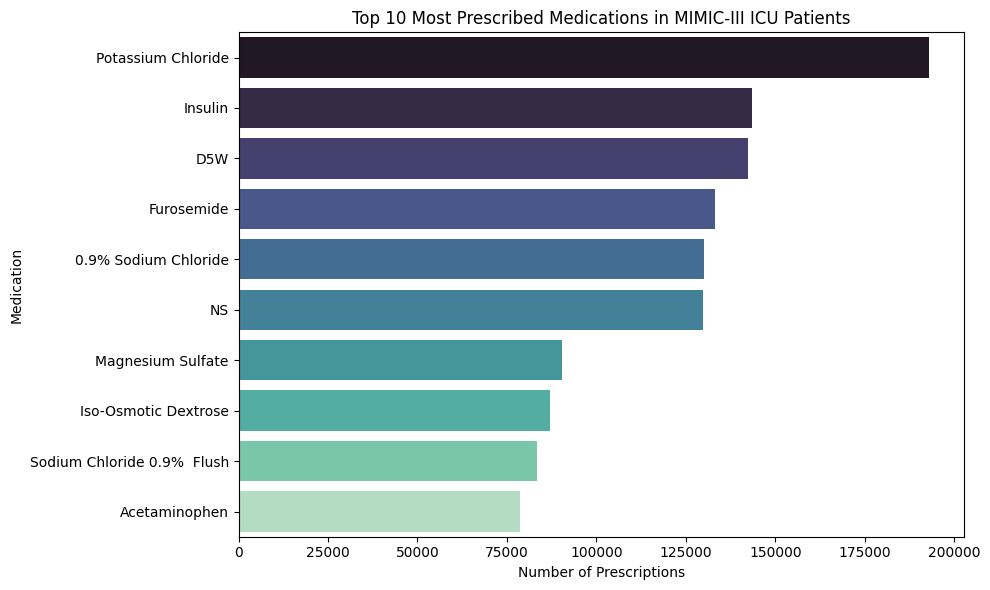

In [7]:
query1 = """
SELECT drug, COUNT(*) as prescription_count
FROM `physionet-data.mimiciii_clinical.prescriptions`
WHERE drug IS NOT NULL
GROUP BY drug
ORDER BY prescription_count DESC
LIMIT 10
"""
df1 = client.query(query1).to_dataframe()

plt.figure(figsize=(10,6))
sns.barplot(x='prescription_count', y='drug', data=df1, palette='mako')
plt.title('Top 10 Most Prescribed Medications in MIMIC-III ICU Patients')
plt.xlabel('Number of Prescriptions')
plt.ylabel('Medication')
plt.tight_layout()
plt.show()

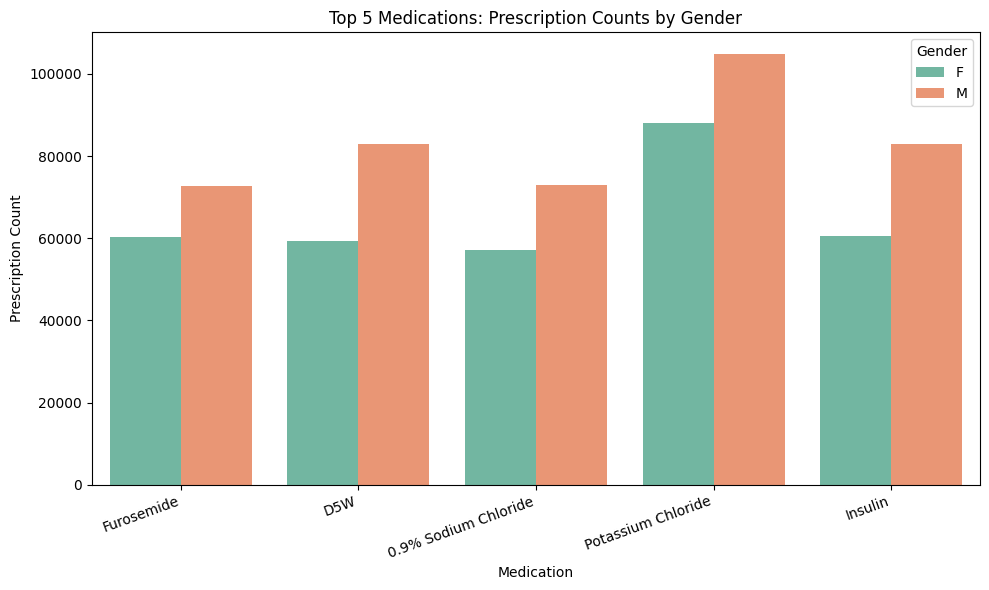

In [8]:
query2 = """
SELECT p.gender, pr.drug, COUNT(*) as count
FROM `physionet-data.mimiciii_clinical.prescriptions` pr
JOIN `physionet-data.mimiciii_clinical.patients` p
ON pr.subject_id = p.subject_id
WHERE pr.drug IN ('Potassium Chloride','Insulin','Furosemide','D5W','0.9% Sodium Chloride')
GROUP BY p.gender, pr.drug
"""
df2 = client.query(query2).to_dataframe()

plt.figure(figsize=(10,6))
sns.barplot(x='drug', y='count', hue='gender', data=df2, palette='Set2')
plt.title('Top 5 Medications: Prescription Counts by Gender')
plt.xlabel('Medication')
plt.ylabel('Prescription Count')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1245/361526294.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='outcome', y='valuenum', data=df3, palette='Set2')


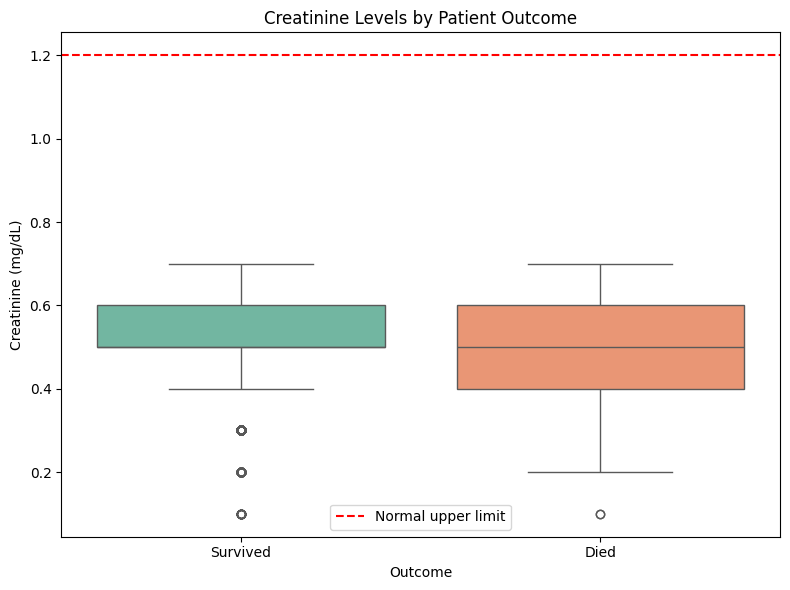

In [9]:
query3 = """
SELECT a.hospital_expire_flag, l.valuenum
FROM `physionet-data.mimiciii_clinical.labevents` l
JOIN `physionet-data.mimiciii_clinical.admissions` a
ON l.hadm_id = a.hadm_id
JOIN `physionet-data.mimiciii_clinical.d_labitems` d
ON l.itemid = d.itemid
WHERE d.label = 'Creatinine'
AND l.valuenum IS NOT NULL
AND l.valuenum BETWEEN 0.1 AND 15
LIMIT 5000
"""
df3 = client.query(query3).to_dataframe()
df3['outcome'] = df3['hospital_expire_flag'].map({0: 'Survived', 1: 'Died'})

plt.figure(figsize=(8,6))
sns.boxplot(x='outcome', y='valuenum', data=df3, palette='Set2')
plt.title('Creatinine Levels by Patient Outcome')
plt.xlabel('Outcome')
plt.ylabel('Creatinine (mg/dL)')
plt.axhline(y=1.2, color='red', linestyle='--', label='Normal upper limit')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
import plotly.express as px

query4 = """
SELECT org_name, COUNT(*) as count
FROM `physionet-data.mimiciii_clinical.microbiologyevents`
WHERE org_name IS NOT NULL
GROUP BY org_name
ORDER BY count DESC
LIMIT 15
"""
df4 = client.query(query4).to_dataframe()

fig = px.treemap(df4, path=['org_name'], values='count',
                  title='Most Common Organisms Cultured in MIMIC-III Microbiology Events',
                  color='count', color_continuous_scale='Reds')
fig.show()

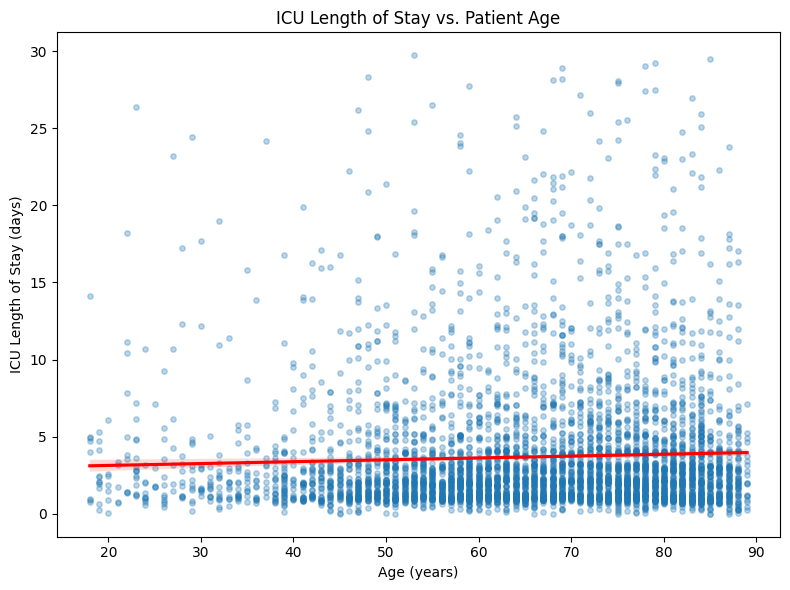

In [11]:
query5 = """
SELECT
  i.los,
  DATE_DIFF(DATE(a.admittime), DATE(p.dob), YEAR) as age
FROM `physionet-data.mimiciii_clinical.icustays` i
JOIN `physionet-data.mimiciii_clinical.admissions` a
ON i.hadm_id = a.hadm_id
JOIN `physionet-data.mimiciii_clinical.patients` p
ON i.subject_id = p.subject_id
WHERE i.los IS NOT NULL
AND i.los BETWEEN 0 AND 30
LIMIT 5000
"""
df5 = client.query(query5).to_dataframe()
df5 = df5[(df5['age'] > 0) & (df5['age'] < 120)]  # filter the 300+ year old artifacts

plt.figure(figsize=(8,6))
sns.regplot(x='age', y='los', data=df5, scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'red'})
plt.title('ICU Length of Stay vs. Patient Age')
plt.xlabel('Age (years)')
plt.ylabel('ICU Length of Stay (days)')
plt.tight_layout()
plt.show()